### Treatment Effect Estimation

In [1]:
import pandas as pd

#### load matched cohort 

In [2]:
df_SAT = pd.read_csv("../data/SAT.csv")
df_external_control = pd.read_csv("../data/external_controls.csv")
df_combined = pd.concat([df_SAT, df_external_control]).reset_index(drop=True)

note to Christoph: pytmle does not need a prematched cohort since it uses propensity weighting internally. That's why I fit it here on the whole cohort. you could also try it with the matched ones, but the 1 to 1 matched most likely does not have enough support in the data (i.e., to little events)

#### Initialize and fit PyTMLE

Note: fitting might take several minutes on a personal laptop

In [ ]:
from pytmle import PyTMLE

target_times = [5.0, 10.0, 15.0, 20.0, 25.0, 30.0] # times at which treatment effect should be estimated

tmle = PyTMLE(df_combined, 
              col_event_times="time", 
              col_event_indicator="status", 
              col_group="chemo", 
              target_times=target_times, 
              g_comp=True,
              evalues_benchmark=False)

tmle.fit(bootstrap=False, 
         n_jobs=-1)

c:\Users\aweller\Documents\r4r-training\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Estimating propensity scores...
Estimating hazards and event-free survival...
Estimating censoring survival...


c:\Users\aweller\Documents\r4r-training\.venv\Lib\site-packages\pytmle\initial_estimates_default_models.py:37: UserWarning: Default DeepHit model not available: No module named 'torch'. Will only cross-fit Cox PH and random survival forest.
  warnings.warn(


Starting TMLE update loop...


(<Figure size 1400x700 with 2 Axes>,
 array([<Axes: title={'center': 'Event 1'}, xlabel='Time', ylabel='Predicted Risk'>,
        <Axes: title={'center': 'Event 2'}, xlabel='Time', ylabel='Predicted Risk'>],
       dtype=object))

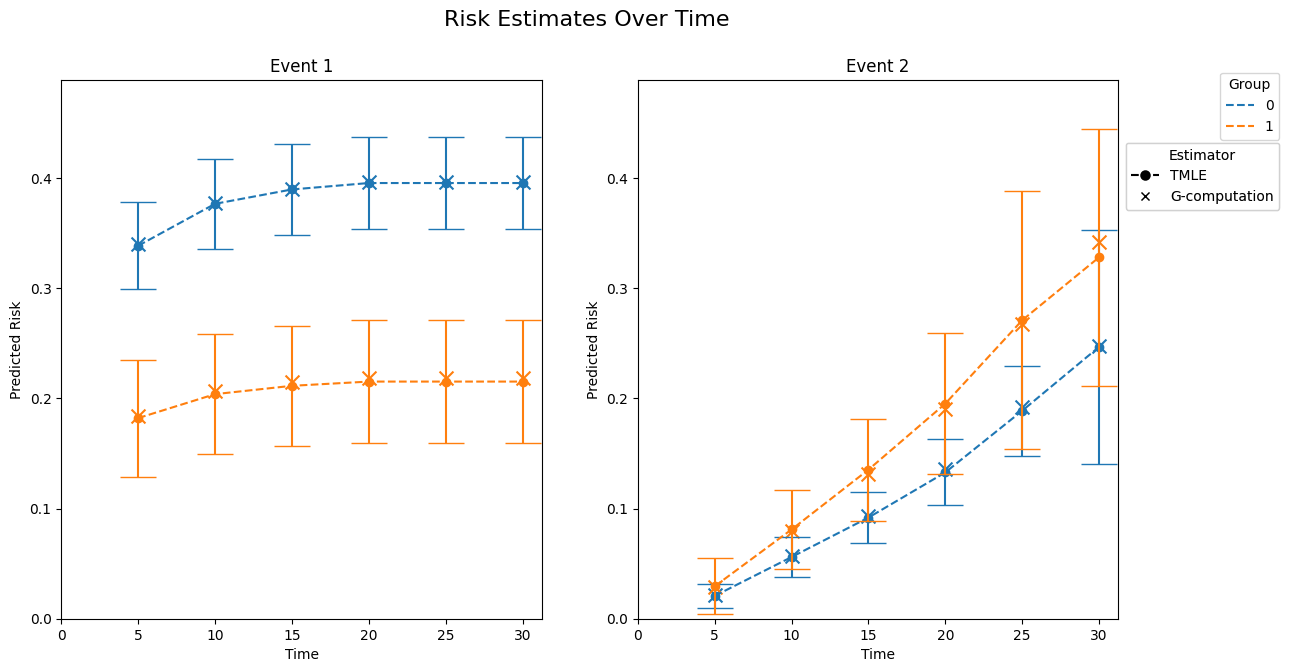

In [ ]:
tmle.plot(g_comp=True, use_bootstrap=False)

### Refutation Tests

Refutation tests deliberately change the treatment assignment or data structure and show how the estimated treatment effect responds. They do not prove that the causal assumptions are correct, but they provide useful diagnostic checks.

- **Random treatment:** randomly permute the treatment labels while preserving the number of treated and control participants. The placebo effects should generally be centered near zero.

The red line marks the risk difference estimated from the original data. Ten simulations keep the exercise quick; more simulations give smoother violin plots.

c:\Users\aweller\Documents\r4r-training\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Estimating propensity scores...
Estimating hazards and event-free survival...
Estimating censoring survival...


c:\Users\aweller\Documents\r4r-training\.venv\Lib\site-packages\pytmle\initial_estimates_default_models.py:37: UserWarning: Default DeepHit model not available: No module named 'torch'. Will only cross-fit Cox PH and random survival forest.
  warnings.warn(


Starting TMLE update loop...
TMLE converged at step 2.
Estimating propensity scores...
Estimating hazards and event-free survival...
Estimating censoring survival...


c:\Users\aweller\Documents\r4r-training\.venv\Lib\site-packages\pytmle\initial_estimates_default_models.py:37: UserWarning: Default DeepHit model not available: No module named 'torch'. Will only cross-fit Cox PH and random survival forest.
  warnings.warn(


Starting TMLE update loop...
TMLE converged at step 2.
Estimating propensity scores...
Estimating hazards and event-free survival...
Estimating censoring survival...


c:\Users\aweller\Documents\r4r-training\.venv\Lib\site-packages\pytmle\initial_estimates_default_models.py:37: UserWarning: Default DeepHit model not available: No module named 'torch'. Will only cross-fit Cox PH and random survival forest.
  warnings.warn(


Starting TMLE update loop...
TMLE converged at step 1.


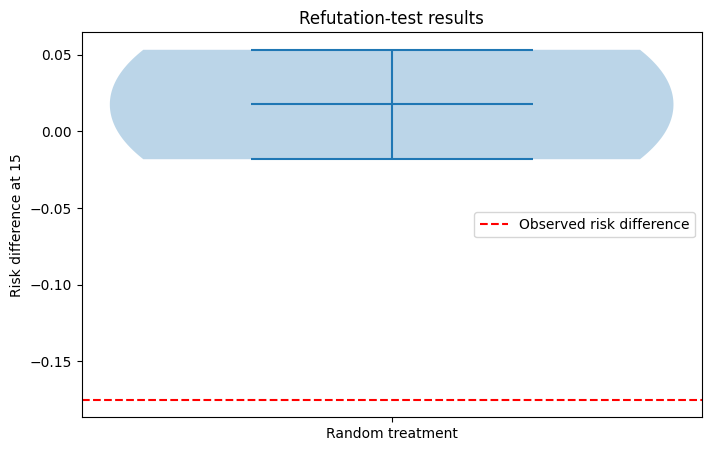

In [ ]:
from R4R_tools.refutation_tests import (
    random_treatment_refutation_pytmle,
)
import matplotlib.pyplot as plt

refutation_time = 15.0
n_simulations = 10
refutation_target_times = [refutation_time]
fit_kwargs = {"bootstrap": False, "n_jobs": -1}

random_treatment_result = random_treatment_refutation_pytmle(
    data=df_combined,
    target_times=refutation_target_times,
    refutation_time=refutation_time,
    col_event_times="time",
    col_event_indicator="status",
    treatment_col="chemo",
    n_simulations=n_simulations,
    random_state=42,
    fit_kwargs=fit_kwargs,
)

observed_effect = random_treatment_result["observed_effect"]
refutation_effects = [
    random_treatment_result["placebo_effects"],
]

plt.figure(figsize=(8, 5))
plt.violinplot(refutation_effects, showmeans=True)
plt.axhline(
    observed_effect,
    color="red",
    linestyle="--",
    label="Observed risk difference",
)
plt.xticks([1], ["Random treatment"])
plt.ylabel(f"Risk difference at {refutation_time:g}")
plt.title("Refutation-test results")
plt.legend()
plt.show()

Possible Questions / Tests:

- fit pytmle on matched cohort and see if similar effect (direction) is estimated
- random common cause refutation: add an irrelevant random covariate and refit pyTMLE. what do you expect? (--> the estimated effects should remain broadly similar to the original effect)

In [ ]:
from R4R_tools.refutation_tests import (
    random_common_cause_refutation_pytmle,
)
import matplotlib.pyplot as plt

refutation_time = 15.0
n_simulations = 10
refutation_target_times = [refutation_time]
fit_kwargs = {"bootstrap": False, "n_jobs": -1}

random_treatment_result = random_common_cause_refutation_pytmle(
    data=df_combined,
    target_times=refutation_target_times,
    refutation_time=refutation_time,
    col_event_times="time",
    col_event_indicator="status",
    treatment_col="chemo",
    n_simulations=n_simulations,
    random_state=42,
    fit_kwargs=fit_kwargs,
)

observed_effect = random_treatment_result["observed_effect"]
refutation_effects = [
    random_treatment_result["placebo_effects"],
]

plt.figure(figsize=(8, 5))
plt.violinplot(refutation_effects, showmeans=True)
plt.axhline(
    observed_effect,
    color="red",
    linestyle="--",
    label="Observed risk difference",
)
plt.xticks([1], ["Random common cause"])
plt.ylabel(f"Risk difference at {refutation_time:g}")
plt.title("Refutation-test results")
plt.legend()
plt.show()